### Imports

In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

from sklearn import set_config
#this code will make it so that whenever we transform data the output is a DataFrame
set_config(transform_output='pandas')

In [ ]:
sklearn.__version__

'1.6.1'

###Loading in the Data

In [ ]:
url = 'https://drive.google.com/file/d/1WsKRDZoNuX0AvE3qcOPYXZY_OQ_WbbAA/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]

data = pd.read_csv(path)
data.head(3)

,LotArea,LotFrontage,TotalBsmtSF,BedroomAbvGr,Fireplaces,PoolArea,GarageCars,WoodDeckSF,ScreenPorch,Expensive
0,8450,65.0,856,3,0,0,2,0,0,0
1,9600,80.0,1262,3,1,0,2,298,0,0
2,11250,68.0,920,3,1,0,2,0,0,0


###Define X and y

In [ ]:
X = data
y = X.pop('Expensive')

###Data Splitting (Train - Test)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=31416)

### Dealing with missing data

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 772 to 1391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LotArea       1168 non-null   int64  
 1   LotFrontage   966 non-null    float64
 2   TotalBsmtSF   1168 non-null   int64  
 3   BedroomAbvGr  1168 non-null   int64  
 4   Fireplaces    1168 non-null   int64  
 5   PoolArea      1168 non-null   int64  
 6   GarageCars    1168 non-null   int64  
 7   WoodDeckSF    1168 non-null   int64  
 8   ScreenPorch   1168 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 91.2 KB


In [ ]:
X_train.isna().sum()

,0
LotArea,0
LotFrontage,202
TotalBsmtSF,0
BedroomAbvGr,0
Fireplaces,0
PoolArea,0
GarageCars,0
WoodDeckSF,0
ScreenPorch,0


* total usually: 1168
* LotFrontage has 202 NaNs

In [ ]:
from sklearn.impute import SimpleImputer

Follow this approach for different types of estimators:

1. initialize,
2. use fit on the train set,
3. use transform on the train set,
4. use transform on the test set.
* (It is possible to combine steps 2 and 3 and use fit_transform instead.)

In [ ]:
# 1. Initialise
my_imputer = SimpleImputer()

In [ ]:
# 2. use fit on the TRAIN set
my_imputer.fit(X_train)

SimpleImputer()

In [ ]:
# 3. use transform on the TRAIN set
X_imputed_train = my_imputer.transform(X_train)

In [ ]:
X_imputed_train.isnull().sum() ## checking for NaNs, and all gone

,0
LotArea,0
LotFrontage,0
TotalBsmtSF,0
BedroomAbvGr,0
Fireplaces,0
PoolArea,0
GarageCars,0
WoodDeckSF,0
ScreenPorch,0


### Implementing a Decision Tree (without missing values / imputed values)

In [ ]:
# 1. import the model
from sklearn.tree import DecisionTreeClassifier

# 2. initialise the model (optional: give some parameters)
my_tree = DecisionTreeClassifier()

# 3. fit the model to the TRAIN data
my_tree.fit(X = X_imputed_train, y = y_train)

DecisionTreeClassifier()

### Make predicitions and check accuracy on the TRAIN set

.predict() method: you pass in the input data (X_num_imputed_train) for which you want to predict the target variable (or class labels).

In [ ]:
# make predictions
y_pred_tree_train = my_tree.predict(X_imputed_train)

In [ ]:
y_pred_tree_train

array([0, 1, 0, ..., 0, 1, 0])

In [ ]:
# check accuracy on the TRAIN set
from sklearn.metrics import accuracy_score

accuracy_score(y_true= y_train,
               y_pred= y_pred_tree_train
               )

1.0

100%? That seems a LOT off

### Check accuracy for the TEST set

In [ ]:
# @title Transform the TEST set
# impute NaN's to the TEST set

X_imputed_test = my_imputer.transform(X_test)

In [ ]:
# @title Make predictions on the TEST set

y_pred_tree_test = my_tree.predict(X_imputed_test)

In [ ]:
# @title Check accuracy score on the TEST set

accuracy_score(y_true= y_test,
               y_pred= y_pred_tree_test
              )

0.8698630136986302

### Plotting the Decision Tree

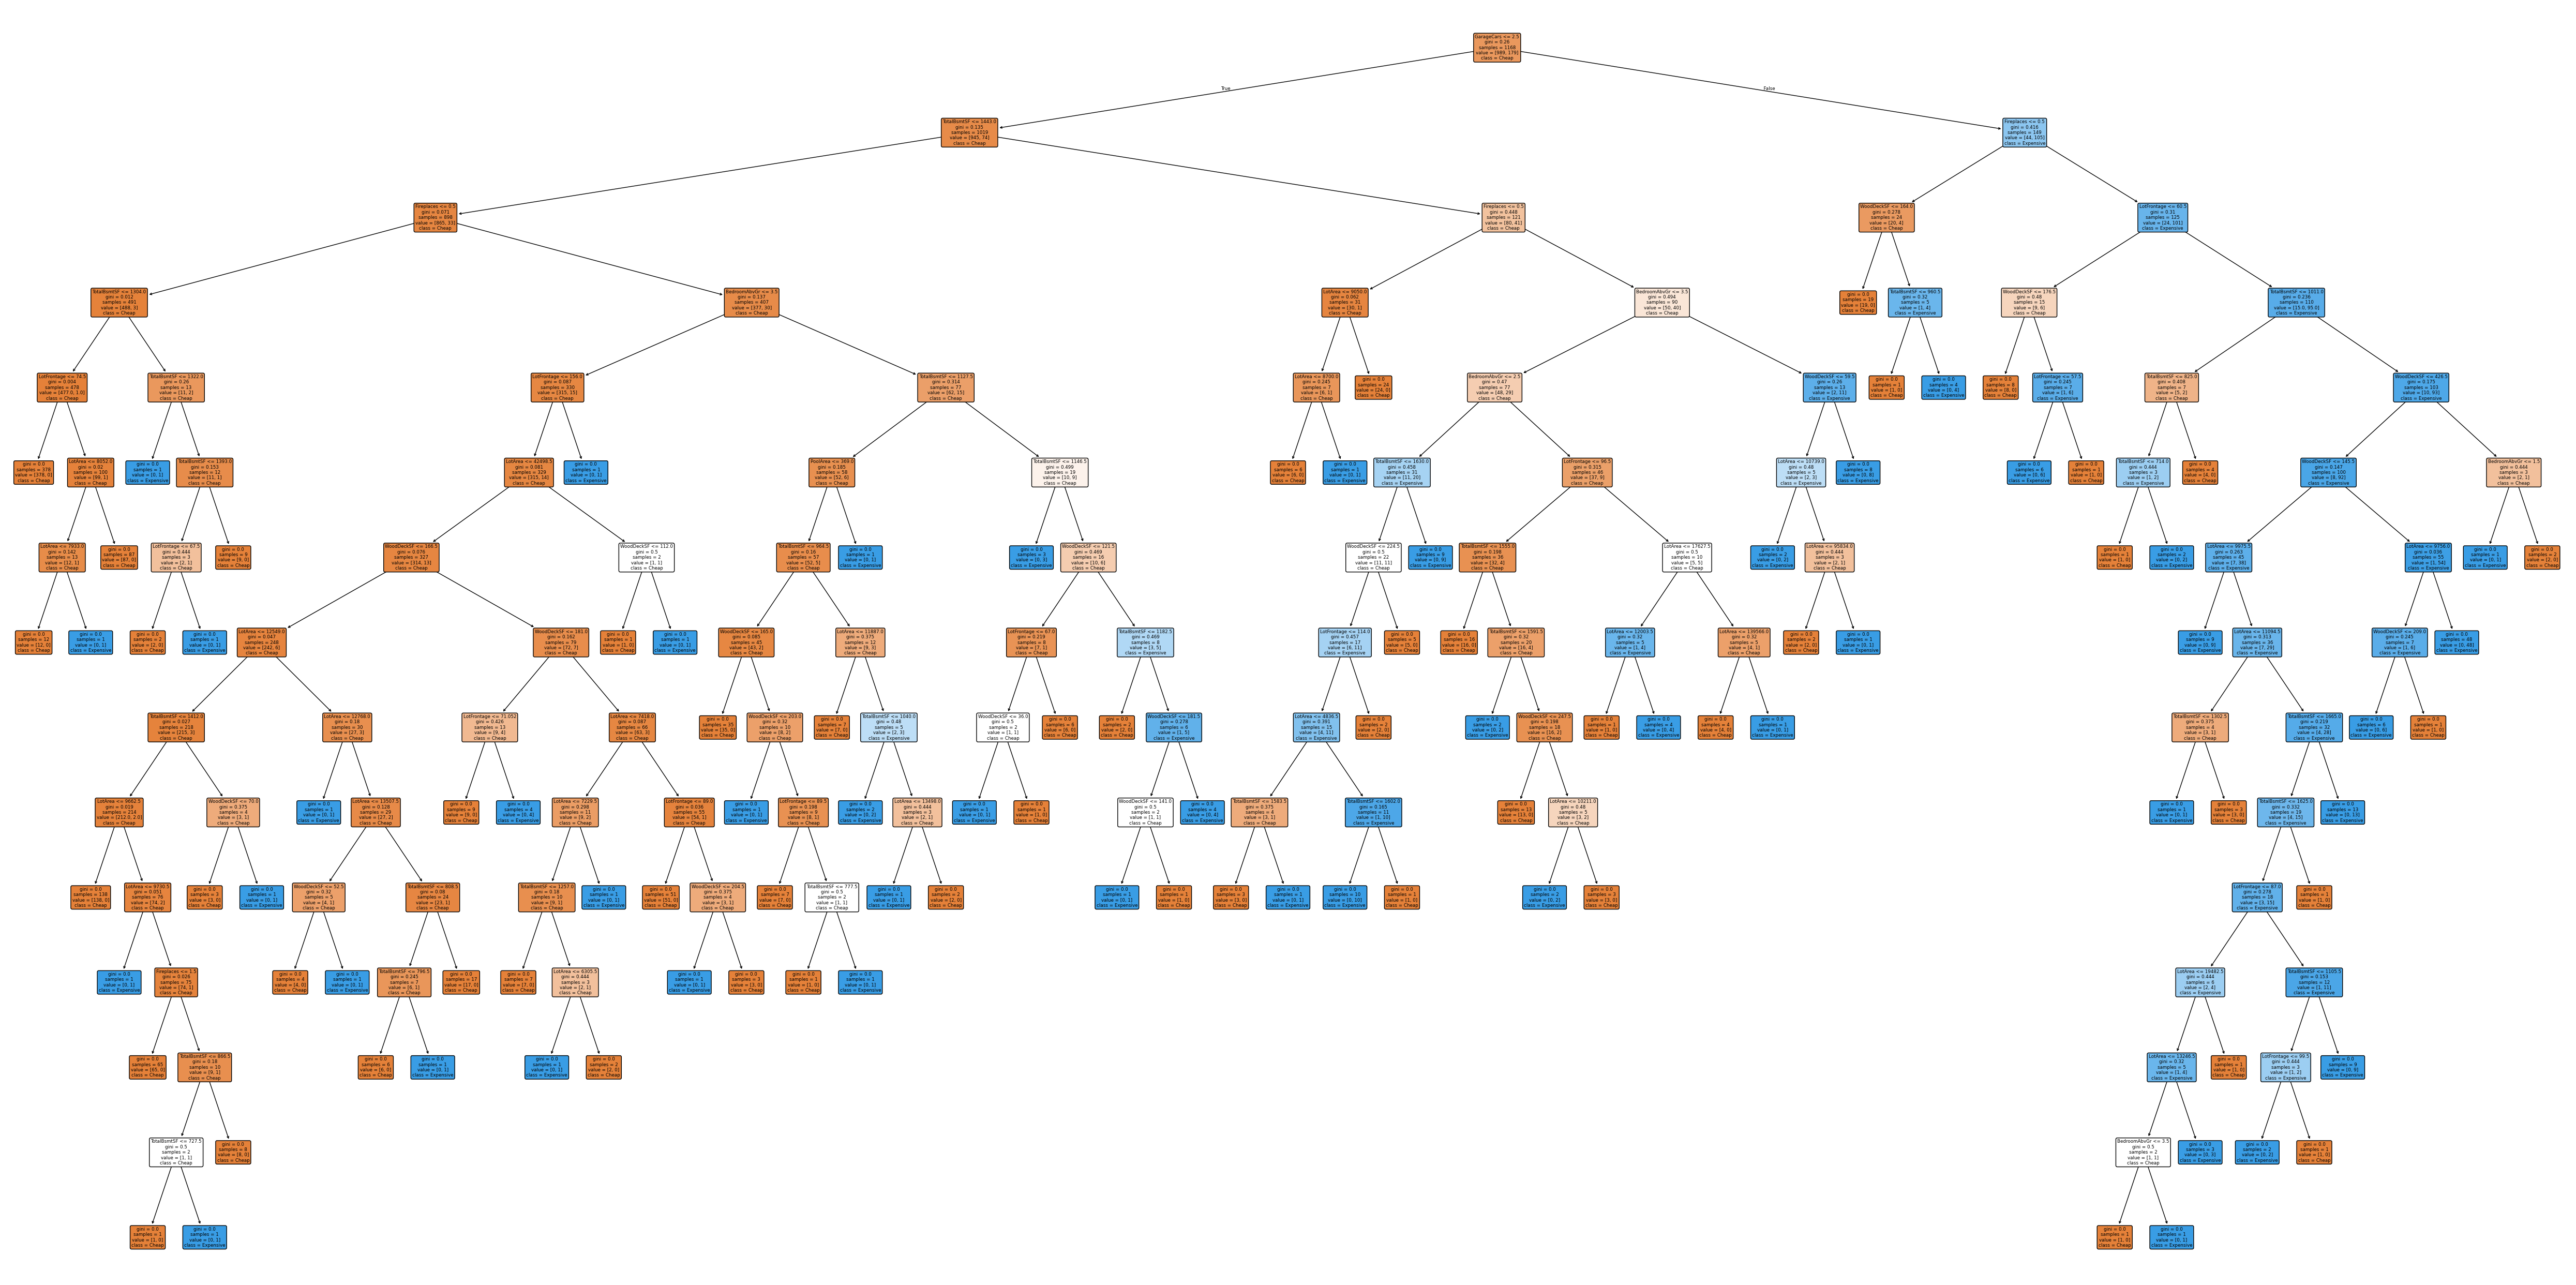

In [ ]:
from sklearn.tree import plot_tree

tree_plot = plt.figure(figsize=(64, 32))

plot_tree(
    my_tree,
    filled=True,
    rounded=True,
    class_names=['Cheap', 'Expensive'],
    feature_names=X.columns
    )

tree_plot;

In [ ]:
# this is really hard to read, so we can save it. svg files are highly enlargeable, so it's a decent file choice
tree_plot.savefig("tree.svg")

### Pruning the tree

In [ ]:
# different models
#my_tree = DecisionTreeClassifier(max_depth=4) # Train: 0.9332, Test: 0.9247
#my_tree = DecisionTreeClassifier(min_samples_leaf=8) # Train: 0.9375, Test: 0.9315
my_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=7) # Train: 0.9298, Test: 0.9281

# fit the model to the TRAIN!! data
my_tree.fit(X= X_imputed_train,
            y = y_train)

print(f'Train: {round(accuracy_score(y_true= y_train, y_pred=my_tree.predict(X_imputed_train)), 4)}')
print(f'Test: {round(accuracy_score(y_true= y_test, y_pred=my_tree.predict(X_imputed_test)), 4)}')


Train: 0.9298
Test: 0.9281


### Visualising Hyperparameters

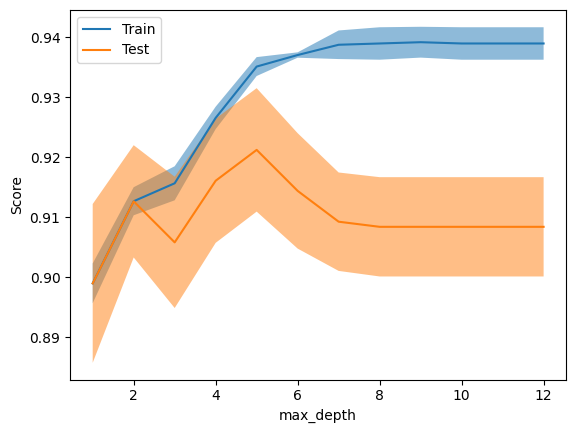

In [ ]:
from sklearn.model_selection import ValidationCurveDisplay

depths= [1,2,3,4,5,6,7,8,9,10,11,12]

# Parameter max_depth
ValidationCurveDisplay.from_estimator(
    estimator=my_tree,
    X=X_imputed_train,
    y=y_train,
    param_name='max_depth',
    param_range= depths
);

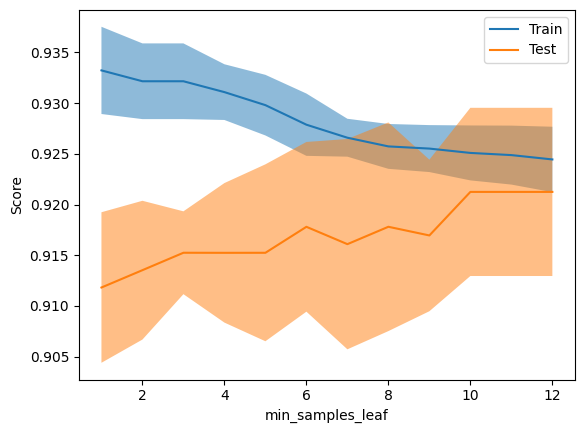

In [ ]:
depths= [1,2,3,4,5,6,7,8,9,10,11,12]

# Parameter max_depth
ValidationCurveDisplay.from_estimator(
    estimator=my_tree,
    X=X_imputed_train,
    y=y_train,
    param_name='min_samples_leaf',
    param_range= depths
);